In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [20]:
# =============================================================================
# STEP 1: UNDERSTANDING THE DATASET
# =============================================================================

from sklearn.datasets import load_breast_cancer

# Breast Cancer Wisconsin (Diagnostic) dataset ships with scikit-learn — no
# CSV download needed (see data/DATA_SOURCES.md). If you switch to a CSV
# copy instead, replace this block with:
#   df = pd.read_csv("../../data/raw/breast_cancer.csv")   # Update path if needed

_data = load_breast_cancer(as_frame=True)
df = pd.concat([_data.data, _data.target.rename("target")], axis=1)
target_names = _data.target_names   # ['malignant', 'benign'] -> target 0 = malignant, 1 = benign


print("=" * 70)
print("DATASET SHAPE")
print("=" * 70)
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")


print("\n" + "=" * 70)
print("FEATURE NAMES")
print("=" * 70)
print(df.columns.tolist())


print("\n" + "=" * 70)
print("FIRST FIVE RECORDS")
print("=" * 70)
display(df.head())


print("\n" + "=" * 70)
print("LAST FIVE RECORDS")
print("=" * 70)
display(df.tail())


print("\n" + "=" * 70)
print("DATASET INFORMATION")
print("=" * 70)
df.info()


print("\n" + "=" * 70)
print("DATA TYPES")
print("=" * 70)
display(df.dtypes.to_frame(name="Data Type"))


print("\n" + "=" * 70)
print("MISSING VALUES OVERVIEW")
print("=" * 70)

missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum()/len(df))*100
})

display(missing_summary)


print("\n" + "=" * 70)
print("DUPLICATE RECORDS")
print("=" * 70)
print(f"Total Duplicate Rows : {df.duplicated().sum()}")


print("\n" + "=" * 70)
print("SUMMARY STATISTICS - NUMERICAL FEATURES")
print("=" * 70)
display(df.describe().T)


print("\n" + "=" * 70)
print("SUMMARY STATISTICS - CATEGORICAL FEATURES")
print("=" * 70)

categorical_cols = df.select_dtypes(include="object").columns

if len(categorical_cols) > 0:
    display(df.describe(include="object").T)
else:
    print("No categorical features found — all 30 predictors are continuous")
    print("morphometric measurements computed from digitized FNA images.")


print("\n" + "=" * 70)
print("MEMORY USAGE")
print("=" * 70)

memory_usage = df.memory_usage(deep=True).sum() / (1024**2)

print(f"Memory Usage : {memory_usage:.2f} MB")

DATASET SHAPE
Rows    : 569
Columns : 31

FEATURE NAMES
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'target']

FIRST FIVE RECORDS


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



LAST FIVE RECORDS


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,1



DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error

...


MISSING VALUES OVERVIEW


,Missing Count,Missing Percentage
mean radius,0,0.0
mean texture,0,0.0
mean perimeter,0,0.0
mean area,0,0.0
mean smoothness,0,0.0
mean compactness,0,0.0
mean concavity,0,0.0
mean concave points,0,0.0
mean symmetry,0,0.0
mean fractal dimension,0,0.0



DUPLICATE RECORDS
Total Duplicate Rows : 0

SUMMARY STATISTICS - NUMERICAL FEATURES


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744



SUMMARY STATISTICS - CATEGORICAL FEATURES
No categorical features found — all 30 predictors are continuous
morphometric measurements computed from digitized FNA images.

MEMORY USAGE
Memory Usage : 0.13 MB


In [21]:
# =============================================================================
# STEP 2: MISSING VALUE ANALYSIS
# =============================================================================


print("=" * 70)
print("MISSING VALUE COUNT")
print("=" * 70)

missing_count = df.isnull().sum()

display(
    missing_count.to_frame(name="Missing Values")
)


print("\n" + "=" * 70)
print("MISSING VALUE PERCENTAGE")
print("=" * 70)

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage (%)": missing_percentage.round(2)
})

display(missing_summary)


print("\n" + "=" * 70)
print("FEATURES WITH MISSING VALUES")
print("=" * 70)

missing_features = missing_summary[
    missing_summary["Missing Count"] > 0
]

if len(missing_features) > 0:
    display(missing_features)
else:
    print("No missing values found in the dataset")


print("\n" + "=" * 70)
print("MISSING VALUE VISUALIZATION")
print("=" * 70)

missing_plot = missing_summary[
    missing_summary["Missing Count"] > 0
]

if len(missing_plot) > 0:
    plt.figure(figsize=(10,5))

    sns.barplot(
        x=missing_plot.index,
        y=missing_plot["Missing Percentage (%)"]
    )

    plt.xticks(rotation=45)
    plt.ylabel("Missing Percentage (%)")
    plt.xlabel("Features")
    plt.title("Missing Value Percentage by Feature")
    plt.show()

else:
    print("No missing values to visualize — the Wisconsin dataset is fully complete.")


print("\n" + "=" * 70)
print("TOTAL MISSING VALUES")
print("=" * 70)

total_missing = df.isnull().sum().sum()

print(f"Total Missing Values : {total_missing}")

MISSING VALUE COUNT


,Missing Values
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0



MISSING VALUE PERCENTAGE


,Missing Count,Missing Percentage (%)
mean radius,0,0.0
mean texture,0,0.0
mean perimeter,0,0.0
mean area,0,0.0
mean smoothness,0,0.0
mean compactness,0,0.0
mean concavity,0,0.0
mean concave points,0,0.0
mean symmetry,0,0.0
mean fractal dimension,0,0.0



FEATURES WITH MISSING VALUES
No missing values found in the dataset

MISSING VALUE VISUALIZATION
No missing values to visualize — the Wisconsin dataset is fully complete.

TOTAL MISSING VALUES
Total Missing Values : 0


In [22]:
# =============================================================================
# STEP 3: DUPLICATE ANALYSIS
# =============================================================================


print("=" * 70)
print("TOTAL DUPLICATE RECORDS")
print("=" * 70)

duplicate_count = df.duplicated().sum()

print(f"Duplicate Rows : {duplicate_count}")


print("\n" + "=" * 70)
print("DUPLICATE PERCENTAGE")
print("=" * 70)

duplicate_percentage = (duplicate_count / len(df)) * 100

print(f"Duplicate Percentage : {duplicate_percentage:.2f}%")


print("\n" + "=" * 70)
print("DUPLICATE RECORDS PREVIEW")
print("=" * 70)

if duplicate_count > 0:

    duplicate_rows = df[df.duplicated(keep=False)]

    display(duplicate_rows.head())

else:
    print("No duplicate records found")


print("\n" + "=" * 70)
print("DATASET SIZE BEFORE DUPLICATE REMOVAL")
print("=" * 70)

print(f"Rows Before Removal : {df.shape[0]}")


print("\n" + "=" * 70)
print("DUPLICATE REMOVAL")
print("=" * 70)

# Create a copy for preprocessing (kept even though 0 are expected here, so
# every downstream cell can consistently reference df_clean regardless of
# dataset — same pattern used in the diabetes EDA notebook)
df_clean = df.drop_duplicates()

print(f"Rows After Removal : {df_clean.shape[0]}")


print("\n" + "=" * 70)
print("ROWS REMOVED")
print("=" * 70)

rows_removed = df.shape[0] - df_clean.shape[0]

print(f"Total Rows Removed : {rows_removed}")

TOTAL DUPLICATE RECORDS
Duplicate Rows : 0

DUPLICATE PERCENTAGE
Duplicate Percentage : 0.00%

DUPLICATE RECORDS PREVIEW
No duplicate records found

DATASET SIZE BEFORE DUPLICATE REMOVAL
Rows Before Removal : 569

DUPLICATE REMOVAL
Rows After Removal : 569

ROWS REMOVED
Total Rows Removed : 0



DUPLICATE RECORD VISUALIZATION


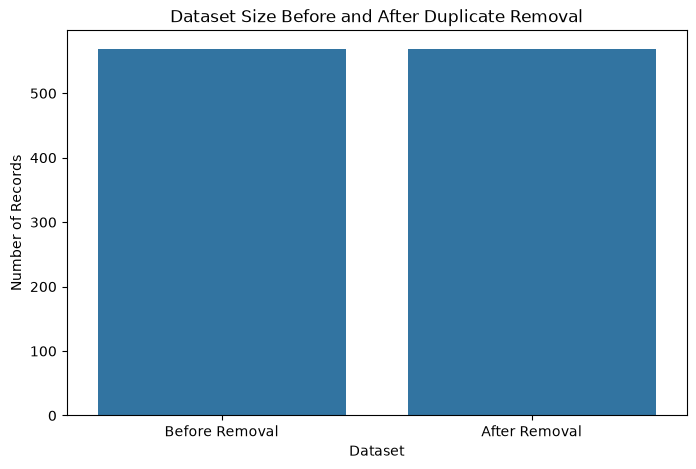


DUPLICATE VS UNIQUE RECORD DISTRIBUTION


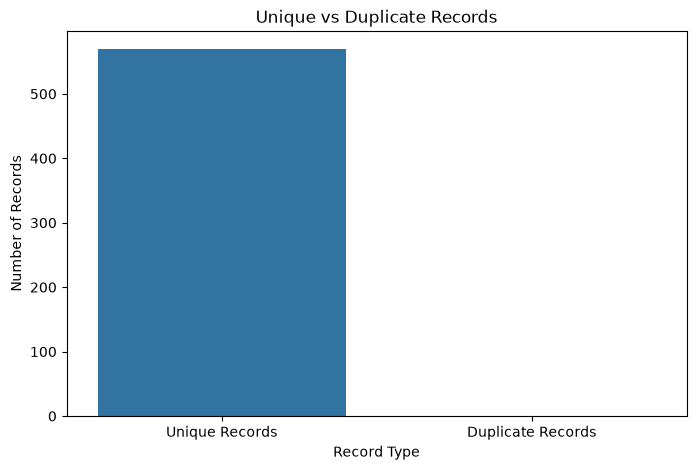

In [23]:
print("\n" + "=" * 70)
print("DUPLICATE RECORD VISUALIZATION")
print("=" * 70)


duplicate_comparison = pd.DataFrame({
    "Dataset": ["Before Removal", "After Removal"],
    "Number of Records": [
        df.shape[0],
        df_clean.shape[0]
    ]
})


plt.figure(figsize=(8,5))

sns.barplot(
    data=duplicate_comparison,
    x="Dataset",
    y="Number of Records"
)

plt.title("Dataset Size Before and After Duplicate Removal")
plt.ylabel("Number of Records")
plt.xlabel("Dataset")
plt.show()


print("\n" + "=" * 70)
print("DUPLICATE VS UNIQUE RECORD DISTRIBUTION")
print("=" * 70)


duplicate_distribution = pd.DataFrame({
    "Record Type": [
        "Unique Records",
        "Duplicate Records"
    ],
    "Count": [
        df_clean.shape[0],
        duplicate_count
    ]
})


plt.figure(figsize=(8,5))

sns.barplot(
    data=duplicate_distribution,
    x="Record Type",
    y="Count"
)

plt.title("Unique vs Duplicate Records")
plt.ylabel("Number of Records")
plt.xlabel("Record Type")
plt.show()

NUMERICAL FEATURES
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

NUMERICAL FEATURE STATISTICS


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744



NUMERICAL FEATURE DISTRIBUTION


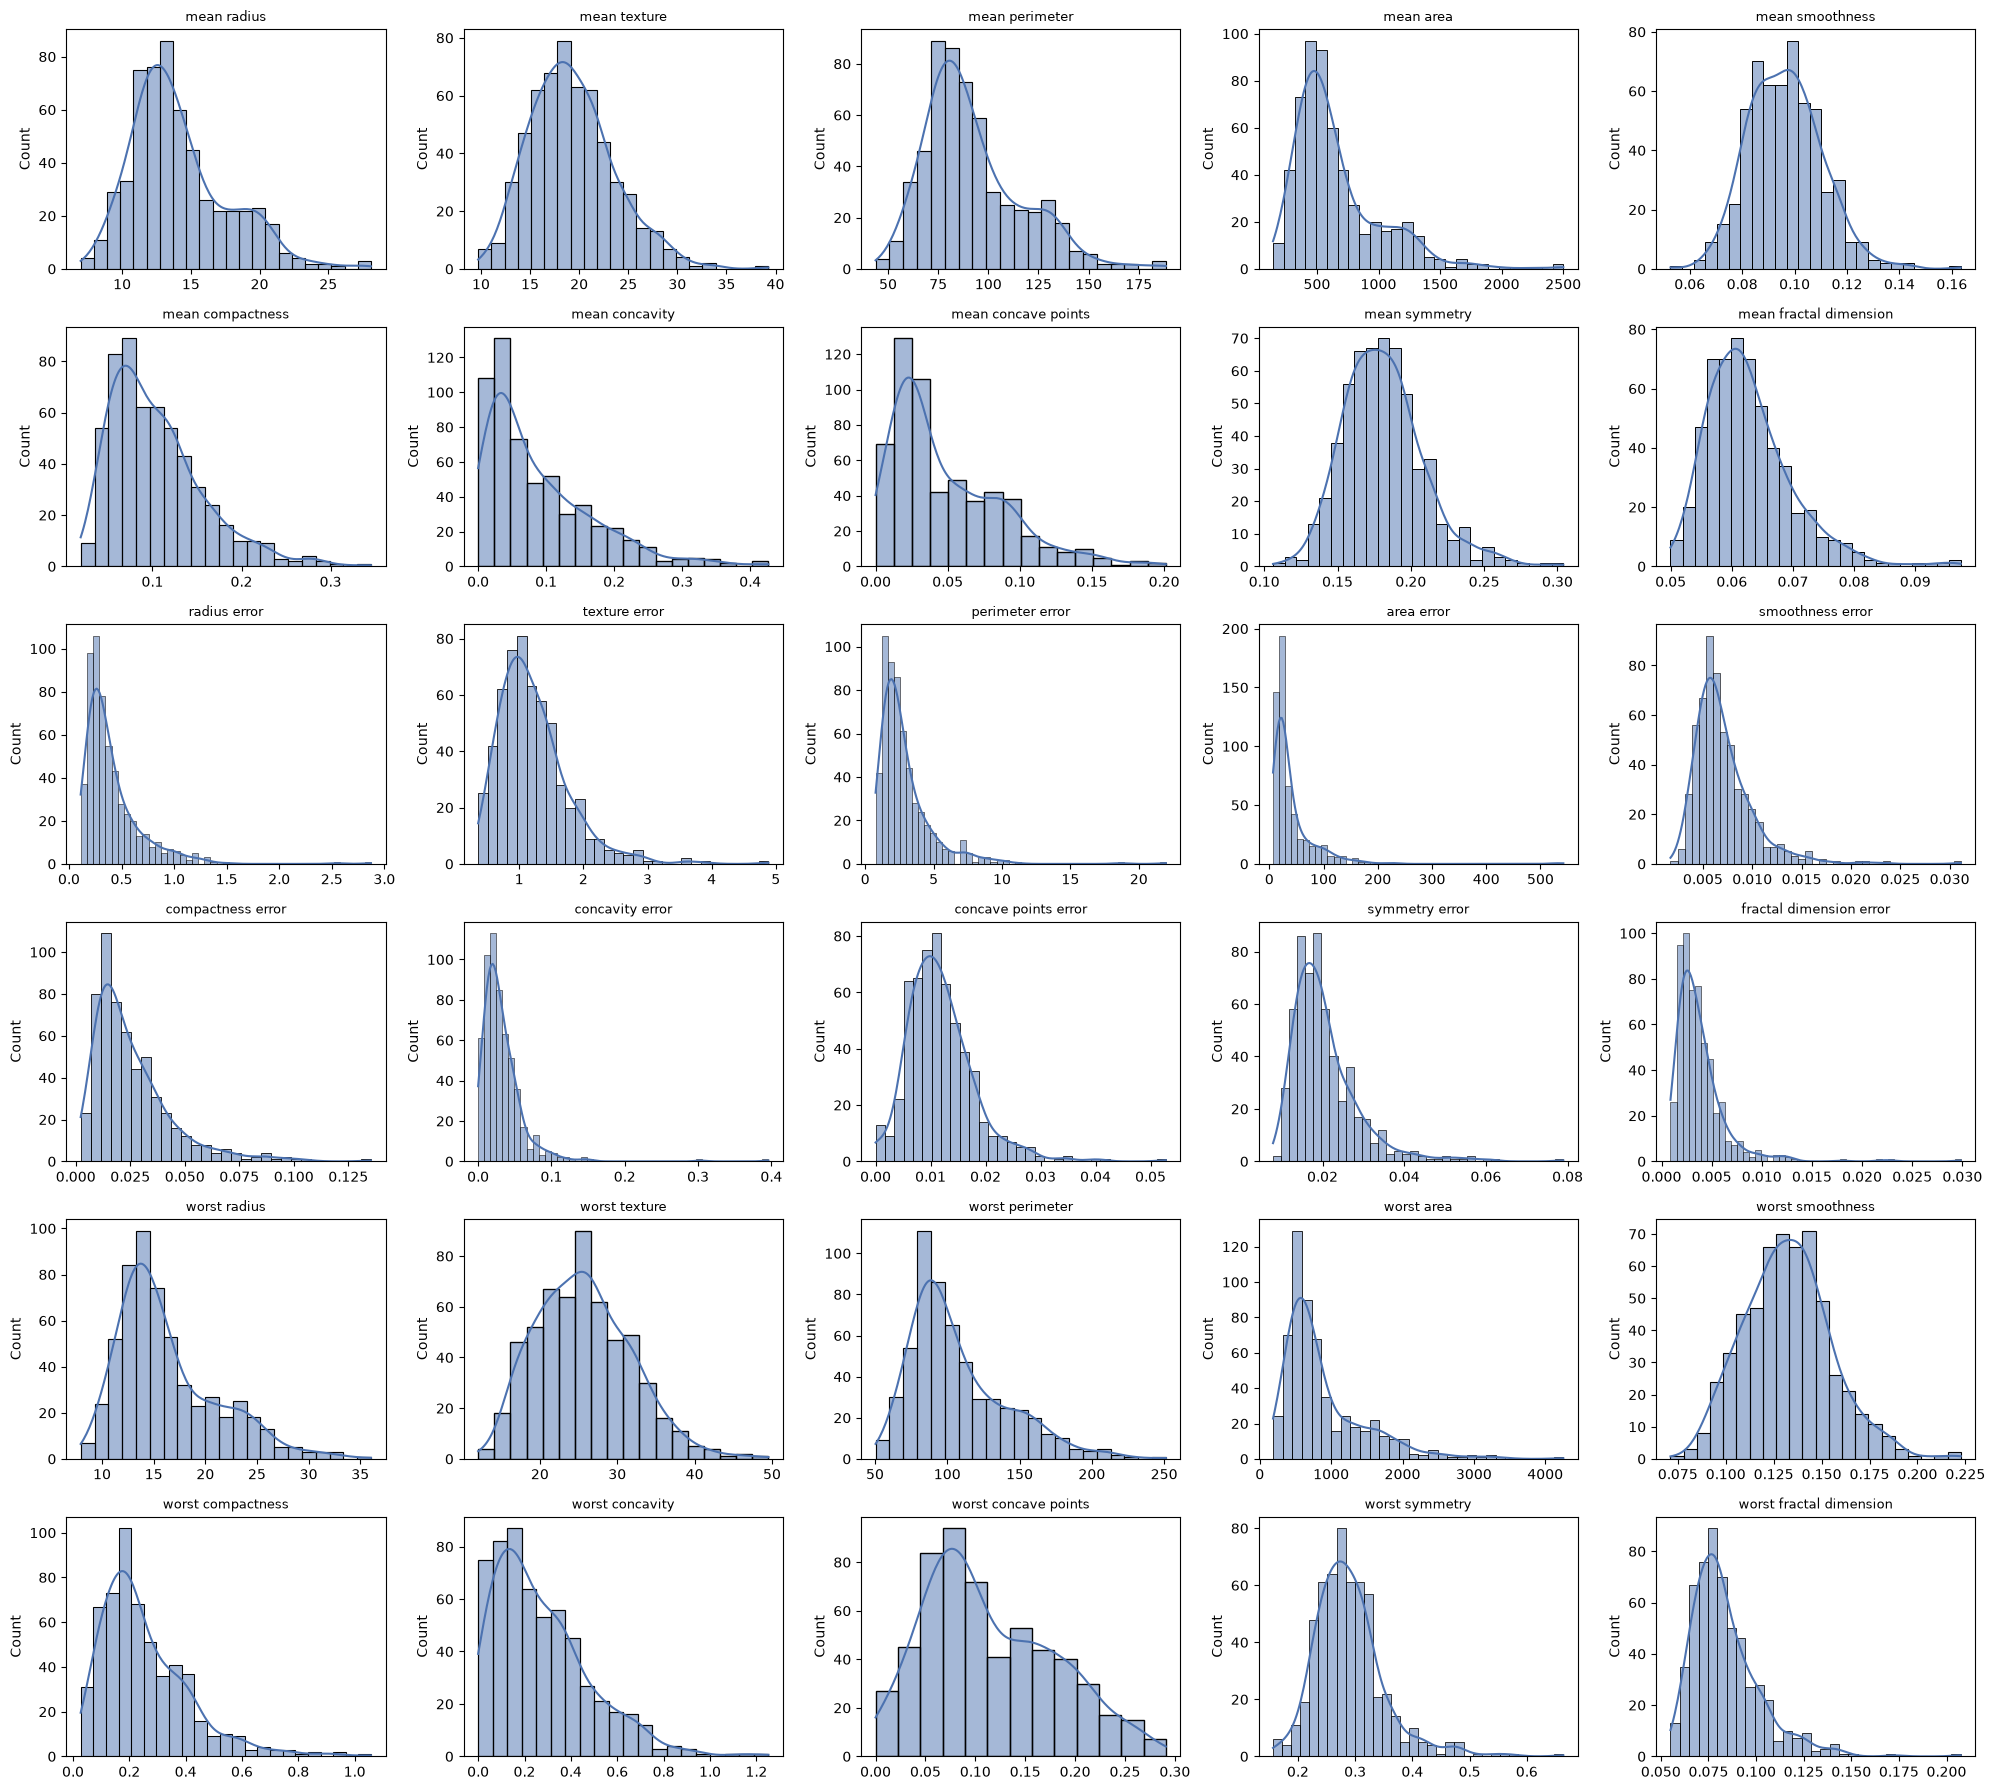

In [24]:
# =============================================================================
# STEP 4: UNIVARIATE ANALYSIS
# =============================================================================


# Use cleaned dataset after duplicate removal
df = df_clean.copy()


print("=" * 70)
print("NUMERICAL FEATURES")
print("=" * 70)


numerical_features = df.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

numerical_features = [f for f in numerical_features if f != "target"]

print(numerical_features)



print("\n" + "=" * 70)
print("NUMERICAL FEATURE STATISTICS")
print("=" * 70)

display(df[numerical_features].describe().T)



print("\n" + "=" * 70)
print("NUMERICAL FEATURE DISTRIBUTION")
print("=" * 70)

# 30 continuous features -> plotted as a 6x5 grid of histograms so every
# feature's distribution shape (skew, spread, potential bimodality) is
# visible in one pass.

n_features = len(numerical_features)
cols = 5
rows = (n_features + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(20, rows*3))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.histplot(df[feature], kde=True, ax=axes[i], color="#4C72B0")
    axes[i].set_title(feature, fontsize=9)
    axes[i].set_xlabel("")

for j in range(i+1, len(axes)):
    axes[j].remove()

plt.tight_layout()
plt.show()

In [25]:
# =============================================================================
# CATEGORICAL / BINARY FEATURE ANALYSIS
# =============================================================================


print("\n" + "=" * 70)
print("CATEGORICAL / BINARY FEATURES")
print("=" * 70)


categorical_features = [
    col for col in df.columns
    if col not in numerical_features + ["target"]
    and df[col].nunique() <= 10
]


print(categorical_features)


print("\n" + "=" * 70)
print("CATEGORICAL FEATURE DISTRIBUTION")
print("=" * 70)

if len(categorical_features) > 0:
    for feature in categorical_features:
        display(
            df[feature]
            .value_counts()
            .to_frame(name="Count")
        )
else:
    print("No categorical/binary predictor features in this dataset — all 30")
    print("predictors are continuous. (The target itself is binary and is")
    print("analyzed separately in Step 7: Class Distribution Analysis.)")


CATEGORICAL / BINARY FEATURES
[]

CATEGORICAL FEATURE DISTRIBUTION
No categorical/binary predictor features in this dataset — all 30
predictors are continuous. (The target itself is binary and is
analyzed separately in Step 7: Class Distribution Analysis.)


In [26]:
# =============================================================================
# STEP 5: OUTLIER ANALYSIS
# =============================================================================


print("=" * 70)
print("NUMERICAL FEATURES FOR OUTLIER ANALYSIS")
print("=" * 70)


# Unlike the diabetes dataset (mostly binary indicators + 3 continuous
# features), all 30 breast cancer predictors are continuous, so outlier
# analysis is run across the full feature set rather than a short list.
print(numerical_features)


print("\n" + "=" * 70)
print("OUTLIER DETECTION USING IQR METHOD")
print("=" * 70)


outlier_summary = []


for feature in numerical_features:

    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR


    outliers = df[
        (df[feature] < lower_limit) |
        (df[feature] > upper_limit)
    ]


    outlier_count = len(outliers)
    outlier_percentage = (outlier_count / len(df)) * 100


    outlier_summary.append({
        "Feature": feature,
        "Lower Bound": round(lower_limit,2),
        "Upper Bound": round(upper_limit,2),
        "Outlier Count": outlier_count,
        "Outlier Percentage (%)": round(outlier_percentage,2)
    })


outlier_df = pd.DataFrame(outlier_summary).sort_values(
    "Outlier Percentage (%)", ascending=False
).reset_index(drop=True)

display(outlier_df)

NUMERICAL FEATURES FOR OUTLIER ANALYSIS
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

OUTLIER DETECTION USING IQR METHOD


,Feature,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage (%)
0,area error,-23.16,86.20,65,11.42
1,radius error,-0.14,0.85,38,6.68
2,perimeter error,-1.02,5.98,38,6.68
3,worst area,-337.75,1937.05,35,6.15
4,smoothness error,0.00,0.01,30,5.27
5,fractal dimension error,-0.00,0.01,28,4.92
6,compactness error,-0.02,0.06,28,4.92
7,symmetry error,0.00,0.04,27,4.75
8,mean area,-123.30,1326.30,25,4.39
9,worst fractal dimension,0.04,0.12,24,4.22



BOXPLOT VISUALIZATION (TOP 10 FEATURES BY OUTLIER %)


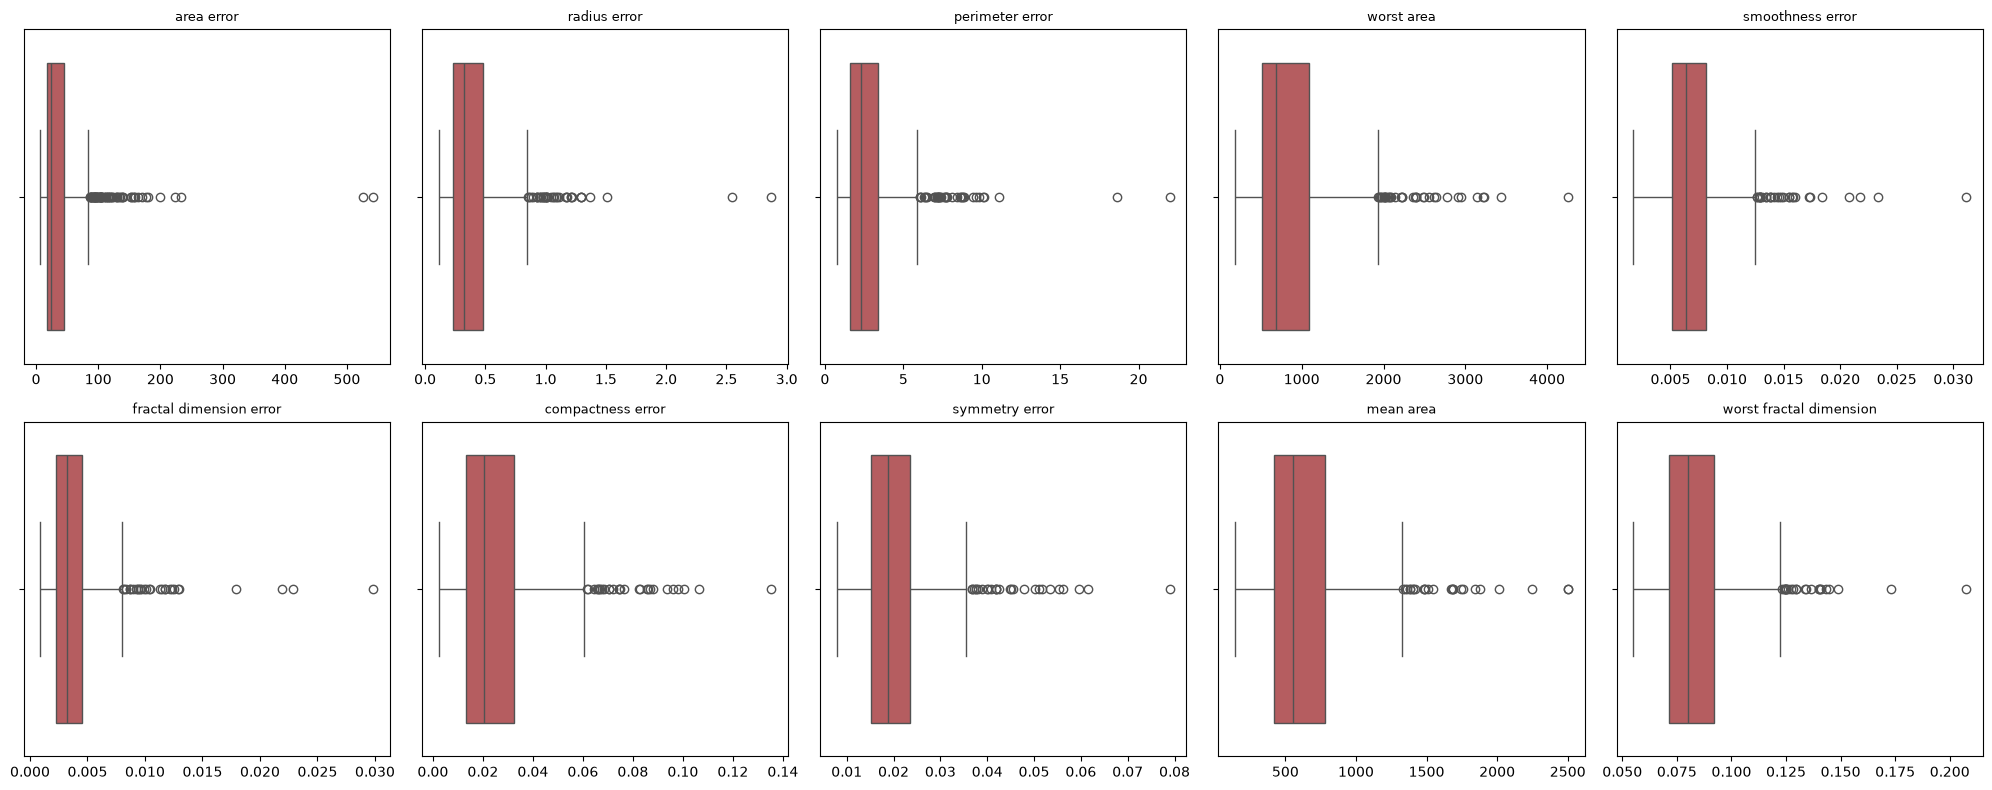

In [27]:
print("\n" + "=" * 70)
print("BOXPLOT VISUALIZATION (TOP 10 FEATURES BY OUTLIER %)")
print("=" * 70)

# 30 individual boxplots is too many to read at once — showing the 10
# features with the highest outlier percentage keeps this readable while
# still surfacing everything worth a second look. The full table above
# already covers all 30.

top_outlier_features = outlier_df.head(10)["Feature"].tolist()

n_features = len(top_outlier_features)
cols = 5
rows = (n_features + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(20, rows*4))
axes = axes.flatten()

for i, feature in enumerate(top_outlier_features):
    sns.boxplot(x=df[feature], ax=axes[i], color="#C44E52")
    axes[i].set_title(f"{feature}", fontsize=9)
    axes[i].set_xlabel("")

for j in range(i+1, len(axes)):
    axes[j].remove()

plt.tight_layout()
plt.show()


OUTLIER PERCENTAGE VISUALIZATION


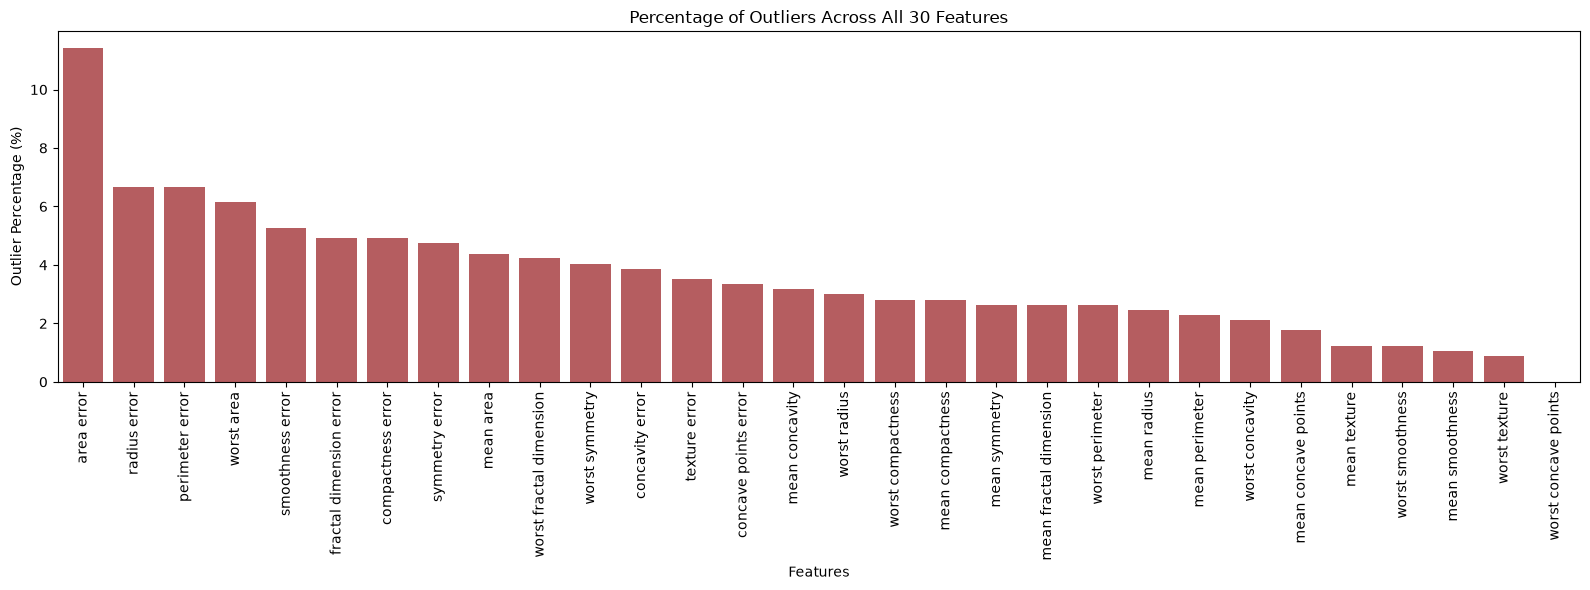

In [28]:
print("\n" + "=" * 70)
print("OUTLIER PERCENTAGE VISUALIZATION")
print("=" * 70)


plt.figure(figsize=(16,6))

sns.barplot(
    data=outlier_df,
    x="Feature",
    y="Outlier Percentage (%)",
    color="#C44E52"
)

plt.title("Percentage of Outliers Across All 30 Features")
plt.xlabel("Features")
plt.ylabel("Outlier Percentage (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

TARGET VARIABLE DISTRIBUTION
target
1    357
0    212
Name: count, dtype: int64

CLASS DISTRIBUTION PERCENTAGE


,Class Count,Percentage (%)
target,,
1,357,62.74
0,212,37.26



CLASS LABEL MAPPING
Class 1 (benign) : 357 samples
Class 0 (malignant) : 212 samples

CLASS DISTRIBUTION VISUALIZATION


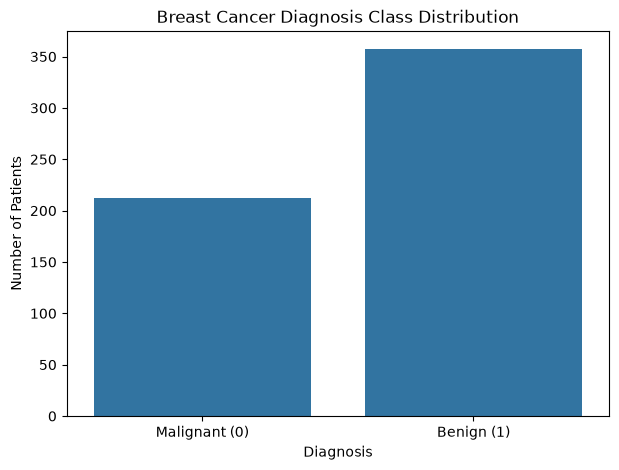


CLASS BALANCE RATIO
Minority/Majority Class Ratio : 0.594
(Mild imbalance — benign cases outnumber malignant roughly 5:3;
not severe enough to require resampling, but worth using
class_weight='balanced' in the DODA modeling notebook regardless.)


In [29]:
# =============================================================================
# STEP 6: CLASS DISTRIBUTION ANALYSIS
# =============================================================================


print("=" * 70)
print("TARGET VARIABLE DISTRIBUTION")
print("=" * 70)


target_column = "target"   # 0 = malignant, 1 = benign


print(df[target_column].value_counts())



print("\n" + "=" * 70)
print("CLASS DISTRIBUTION PERCENTAGE")
print("=" * 70)

class_distribution = pd.DataFrame({
    "Class Count": df[target_column].value_counts(),
    "Percentage (%)": (
        df[target_column]
        .value_counts(normalize=True) * 100
    ).round(2)
})


display(class_distribution)



print("\n" + "=" * 70)
print("CLASS LABEL MAPPING")
print("=" * 70)


for label, count in df[target_column].value_counts().items():
    label_name = target_names[label]
    print(f"Class {label} ({label_name}) : {count} samples")



print("\n" + "=" * 70)
print("CLASS DISTRIBUTION VISUALIZATION")
print("=" * 70)


plt.figure(figsize=(7,5))


sns.countplot(
    data=df,
    x=target_column
)

plt.xticks([0,1], ["Malignant (0)", "Benign (1)"])
plt.title("Breast Cancer Diagnosis Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Patients")
plt.show()



print("\n" + "=" * 70)
print("CLASS BALANCE RATIO")
print("=" * 70)


class_ratio = (
    df[target_column]
    .value_counts()
    .min()
    /
    df[target_column]
    .value_counts()
    .max()
)


print(f"Minority/Majority Class Ratio : {class_ratio:.3f}")
print("(Mild imbalance — benign cases outnumber malignant roughly 5:3;")
print("not severe enough to require resampling, but worth using")
print("class_weight=\'balanced\' in the DODA modeling notebook regardless.)")

In [30]:
# =============================================================================
# STEP 7: CORRELATION ANALYSIS
# =============================================================================


print("=" * 70)
print("CORRELATION MATRIX")
print("=" * 70)


correlation_matrix = df.corr()


display(correlation_matrix.round(2))

CORRELATION MATRIX


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
mean radius,1.00,0.32,1.00,0.99,0.17,0.51,0.68,0.82,0.15,-0.31,...,0.30,0.97,0.94,0.12,0.41,0.53,0.74,0.16,0.01,-0.73
mean texture,0.32,1.00,0.33,0.32,-0.02,0.24,0.30,0.29,0.07,-0.08,...,0.91,0.36,0.34,0.08,0.28,0.30,0.30,0.11,0.12,-0.42
mean perimeter,1.00,0.33,1.00,0.99,0.21,0.56,0.72,0.85,0.18,-0.26,...,0.30,0.97,0.94,0.15,0.46,0.56,0.77,0.19,0.05,-0.74
mean area,0.99,0.32,0.99,1.00,0.18,0.50,0.69,0.82,0.15,-0.28,...,0.29,0.96,0.96,0.12,0.39,0.51,0.72,0.14,0.00,-0.71
mean smoothness,0.17,-0.02,0.21,0.18,1.00,0.66,0.52,0.55,0.56,0.58,...,0.04,0.24,0.21,0.81,0.47,0.43,0.50,0.39,0.50,-0.36
mean compactness,0.51,0.24,0.56,0.50,0.66,1.00,0.88,0.83,0.60,0.57,...,0.25,0.59,0.51,0.57,0.87,0.82,0.82,0.51,0.69,-0.60
mean concavity,0.68,0.30,0.72,0.69,0.52,0.88,1.00,0.92,0.50,0.34,...,0.30,0.73,0.68,0.45,0.75,0.88,0.86,0.41,0.51,-0.70
mean concave points,0.82,0.29,0.85,0.82,0.55,0.83,0.92,1.00,0.46,0.17,...,0.29,0.86,0.81,0.45,0.67,0.75,0.91,0.38,0.37,-0.78
mean symmetry,0.15,0.07,0.18,0.15,0.56,0.60,0.50,0.46,1.00,0.48,...,0.09,0.22,0.18,0.43,0.47,0.43,0.43,0.70,0.44,-0.33
mean fractal dimension,-0.31,-0.08,-0.26,-0.28,0.58,0.57,0.34,0.17,0.48,1.00,...,-0.05,-0.21,-0.23,0.50,0.46,0.35,0.18,0.33,0.77,0.01



CORRELATION HEATMAP


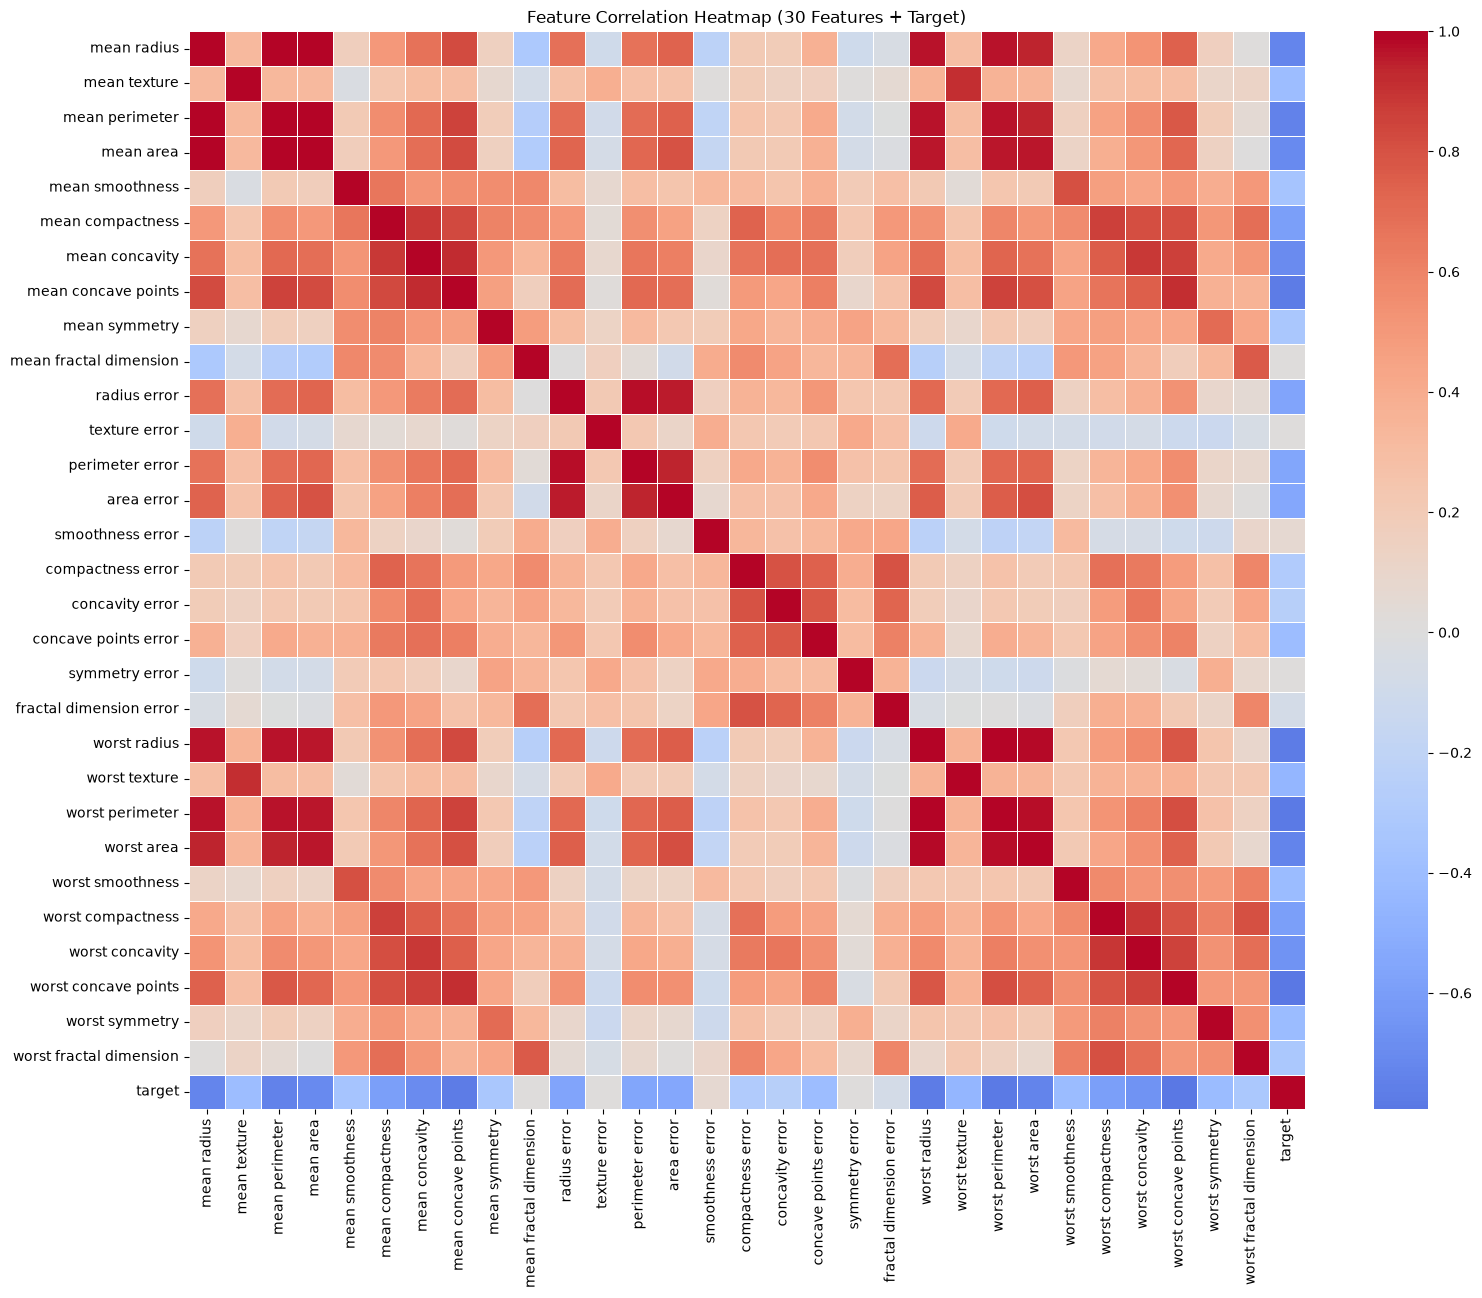


Note: many features are highly intercorrelated (e.g. radius,
perimeter, and area — all describe tumour size) — this redundancy
is exactly what the DODA notebook's feature selection step needs
to account for.


In [31]:
print("\n" + "=" * 70)
print("CORRELATION HEATMAP")
print("=" * 70)


plt.figure(figsize=(18,14))


sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)


plt.title("Feature Correlation Heatmap (30 Features + Target)")
plt.show()

print("\nNote: many features are highly intercorrelated (e.g. radius,")
print("perimeter, and area — all describe tumour size) — this redundancy")
print("is exactly what the DODA notebook's feature selection step needs")
print("to account for.")

In [32]:
# =============================================================================
# STEP 8: RELATIONSHIP WITH TARGET VARIABLE
# =============================================================================


print("=" * 70)
print("TARGET VARIABLE RELATIONSHIP ANALYSIS")
print("=" * 70)


target_column = "target"

# All 30 predictors are numerical here (unlike diabetes, which had mostly
# binary indicators) — so "categorical_features" is empty by construction.
print("Numerical Features (30):")
print(numerical_features)

print("\nCategorical/Binary Features:")
print(categorical_features if categorical_features else "None")

TARGET VARIABLE RELATIONSHIP ANALYSIS
Numerical Features (30):
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

Categorical/Binary Features:
None


In [33]:
print("\n" + "=" * 70)
print("TOP 6 MOST DISCRIMINATIVE FEATURES BY TARGET (describe by group)")
print("=" * 70)

# Ranked by absolute correlation with the target — computed in Step 7.
top_features = (
    correlation_matrix["target"]
    .drop("target")
    .abs()
    .sort_values(ascending=False)
    .head(6)
    .index.tolist()
)

print("Top 6 features:", top_features)

for feature in top_features:
    print("\n")
    print("-"*60)
    print(feature)
    print("-"*60)
    display(
        df.groupby(target_column)[feature]
        .describe()
    )


TOP 6 MOST DISCRIMINATIVE FEATURES BY TARGET (describe by group)
Top 6 features: ['worst concave points', 'worst perimeter', 'mean concave points', 'worst radius', 'mean perimeter', 'worst area']


------------------------------------------------------------
worst concave points
------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,212.0,0.182237,0.046308,0.02899,0.15275,0.18200,0.210675,0.291
1,357.0,0.074444,0.035797,0.00000,0.05104,0.07431,0.097490,0.175




------------------------------------------------------------
worst perimeter
------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,212.0,141.370330,29.457055,85.10,119.325,138.00,159.80,251.2
1,357.0,87.005938,13.527091,50.41,78.270,86.92,96.59,127.1




------------------------------------------------------------
mean concave points
------------------------------------------------------------


...

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,212.0,21.134811,4.283569,12.84,17.73,20.59,23.8075,36.04
1,357.0,13.379801,1.981368,7.93,12.08,13.35,14.8000,19.82




------------------------------------------------------------
mean perimeter
------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,212.0,115.365377,21.854653,71.90,98.745,114.20,129.925,188.5
1,357.0,78.075406,11.807438,43.79,70.870,78.18,86.100,114.6




------------------------------------------------------------
worst area
------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,212.0,1422.286321,597.967743,508.1,970.3,1303.0,1712.75,4254.0
1,357.0,558.899440,163.601424,185.2,447.1,547.4,670.00,1210.0


TOP FEATURES VS DIAGNOSIS


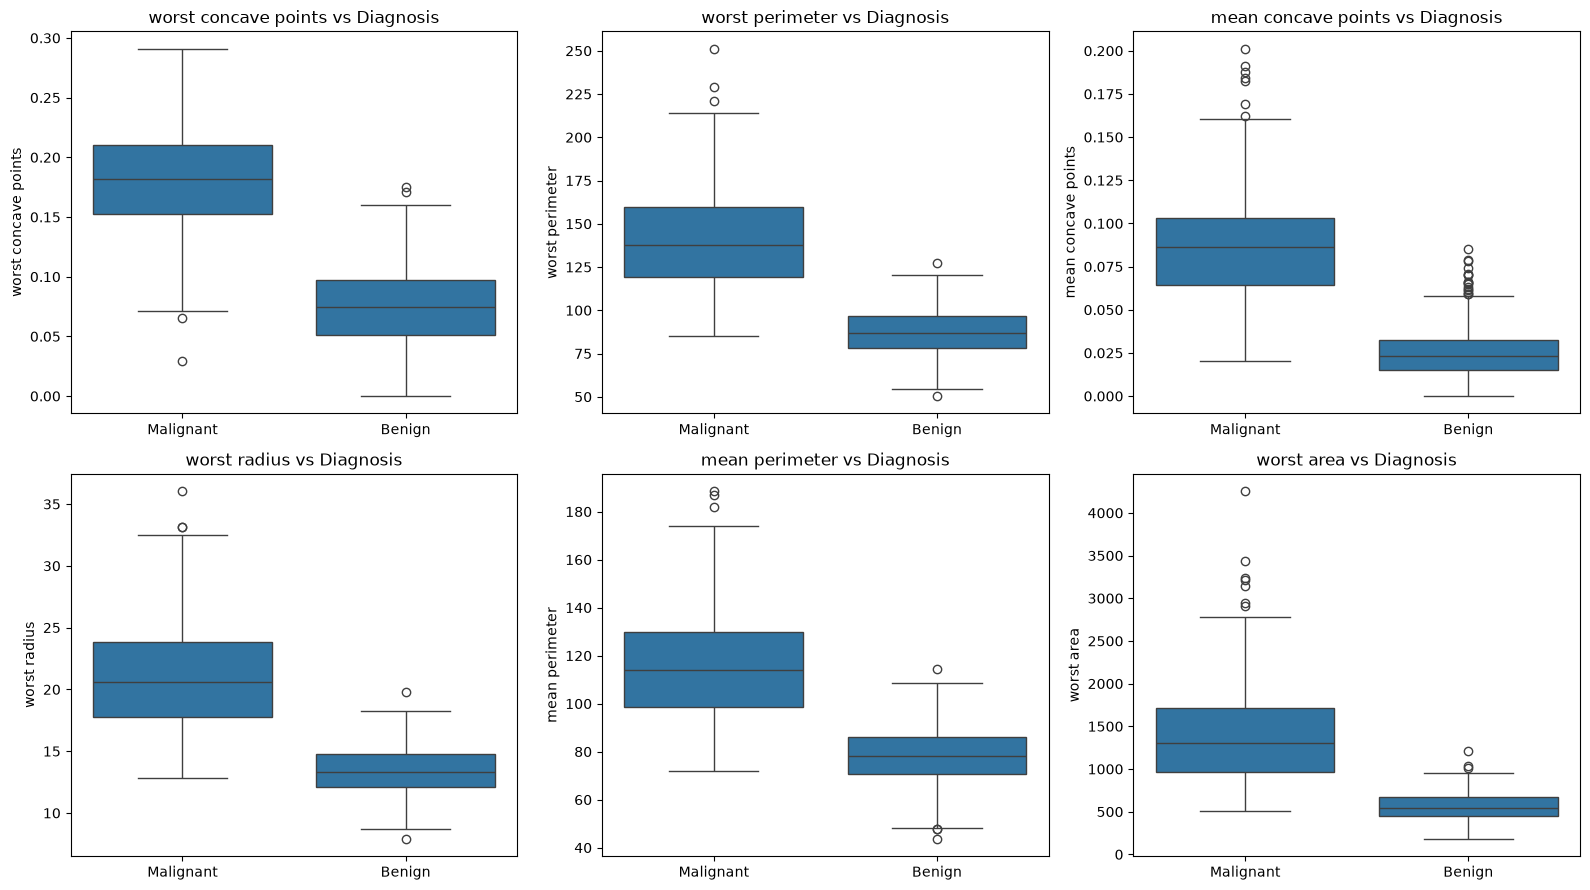


All 6 of the most discriminative features separate malignant from
benign cases clearly — malignant tumours consistently show larger,
more irregular (higher concavity/concave-points) measurements.


In [34]:
# =============================================================================
# NUMERICAL FEATURES VS TARGET (COMBINED VISUALIZATION)
# =============================================================================

print("=" * 70)
print("TOP FEATURES VS DIAGNOSIS")
print("=" * 70)


fig, axes = plt.subplots(2, 3, figsize=(16,9))
axes = axes.flatten()


for i, feature in enumerate(top_features):

    sns.boxplot(
        data=df,
        x=target_column,
        y=feature,
        ax=axes[i]
    )

    axes[i].set_xticklabels(["Malignant", "Benign"])
    axes[i].set_title(f"{feature} vs Diagnosis")
    axes[i].set_xlabel("")


plt.tight_layout()
plt.show()

print("\nAll 6 of the most discriminative features separate malignant from")
print("benign cases clearly — malignant tumours consistently show larger,")
print("more irregular (higher concavity/concave-points) measurements.")

In [35]:
# =============================================================================
# STEP 9: EDA SUMMARY
# =============================================================================


print("=" * 70)
print("EXPLORATORY DATA ANALYSIS SUMMARY")
print("=" * 70)


top_pos_corr = (
    correlation_matrix["target"].drop("target").sort_values(ascending=False).head(3)
)
top_neg_corr = (
    correlation_matrix["target"].drop("target").sort_values().head(3)
)
top_outliers = outlier_df.head(3)

eda_summary = pd.DataFrame({
    "EDA Component": [
        "Dataset Size",
        "Features",
        "Missing Values",
        "Duplicate Records",
        "Target Variable",
        "Class Distribution",
        "Highest Positive Correlation (benign-associated)",
        "Highest Negative Correlation (malignant-associated)",
        "Major Outlier Features"
    ],

    "Findings": [
        f"{df.shape[0]} rows and {df.shape[1]} columns",

        "30 continuous predictors (mean / standard error / worst of 10 base measures)",

        f"{df.isnull().sum().sum()} missing values detected",

        f"{duplicate_count} duplicate rows removed",

        f"{target_column} (0 = malignant, 1 = benign)",

        (
            f"Malignant: {round((df[target_column].value_counts(normalize=True)[0])*100,2)}%, "
            f"Benign: {round((df[target_column].value_counts(normalize=True)[1])*100,2)}%"
        ),

        ", ".join([f"{f} ({v:.3f})" for f, v in top_pos_corr.items()]),

        ", ".join([f"{f} ({v:.3f})" for f, v in top_neg_corr.items()]),

        ", ".join([f"{row.Feature} ({getattr(row, '_5')}%)" for row in top_outliers.itertuples()])
    ]
})

display(eda_summary)

EXPLORATORY DATA ANALYSIS SUMMARY


,EDA Component,Findings
0,Dataset Size,569 rows and 31 columns
1,Features,30 continuous predictors (mean / standard erro...
2,Missing Values,0 missing values detected
3,Duplicate Records,0 duplicate rows removed
4,Target Variable,"target (0 = malignant, 1 = benign)"
5,Class Distribution,"Malignant: 37.26%, Benign: 62.74%"
6,Highest Positive Correlation (benign-associated),"smoothness error (0.067), mean fractal dimensi..."
7,Highest Negative Correlation (malignant-associ...,"worst concave points (-0.794), worst perimeter..."
8,Major Outlier Features,"area error (11.42%), radius error (6.68%), per..."


In [36]:
# =============================================================================
# STEP 10: SAVE CLEANED DATASET
# =============================================================================


import os

os.makedirs("../../data/processed", exist_ok=True)

df_clean.to_csv(
    "../../data/processed/breast_cancer_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully")

print("\nSaved File:")
print("data/processed/breast_cancer_cleaned.csv")

print("\nDataset Shape:")
print(df_clean.shape)

print("\nNext step: 02_breast_cancer_doda.ipynb picks up from here — feature")
print("selection, the DODA clinical re-weighting layer, and model evaluation,")
print("using the shared functions in src/doda.py.")

Cleaned dataset saved successfully

Saved File:
data/processed/breast_cancer_cleaned.csv

Dataset Shape:
(569, 31)

Next step: 02_breast_cancer_doda.ipynb picks up from here — feature
selection, the DODA clinical re-weighting layer, and model evaluation,
using the shared functions in src/doda.py.
